# 00. Check LoCoMotif Installation and API

This diagnostic notebook verifies the real LoCoMotif installation and API usage before integrating it into the thesis benchmark.

It checks whether `dtai-locomotif` is installed, whether the expected Python modules import correctly, whether the real `apply_locomotif` function is available, whether it runs on tiny synthetic inputs, and what output format it returns.

Proxy algorithms, DTW substitutes, placeholder motif results, and fake claims are not allowed in this notebook.

In [1]:
import sys
import os
import subprocess
import json
import inspect
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PACKAGE_NAME = "dtai-locomotif"
OUTPUT_RELATIVE_DIR = Path("reports") / "results" / "locomotif_api_check"

def detect_project_root(start=None):
    """Detect the project root from the current working directory or its parents."""
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "notebooks").exists() and (candidate / "reports").exists():
            return candidate
        if (candidate / "final_dataset").exists() and (candidate / "notebooks").exists():
            return candidate
    return None

PROJECT_ROOT = detect_project_root()
BASE_DIR = PROJECT_ROOT if PROJECT_ROOT is not None else Path.cwd()
OUTPUT_DIR = BASE_DIR / OUTPUT_RELATIVE_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\results\locomotif_api_check


In [2]:
status = {
    "package_name": PACKAGE_NAME,
    "import_name": "locomotif.locomotif",
    "expected_function": "apply_locomotif",
    "package_installed": False,
    "package_imported": False,
    "core_imported": False,
    "visualize_imported": False,
    "apply_locomotif_found": False,
    "apply_locomotif_signature": None,
    "toy_run_successful": False,
    "toy_motif_sets_count": None,
    "toy_parse_successful": False,
    "fake_finance_run_successful": False,
    "fake_finance_parse_successful": False,
    "ready_for_thesis_integration": False,
    "error_messages": [],
}

env_info = {
    "python_executable": sys.executable,
    "python_version": sys.version,
    "current_working_directory": str(Path.cwd().resolve()),
    "project_root": str(PROJECT_ROOT.resolve()) if PROJECT_ROOT is not None else None,
}
status["environment"] = env_info

print("Python executable:", env_info["python_executable"])
print("Python version:", env_info["python_version"])
print("Current working directory:", env_info["current_working_directory"])
print("Project root:", env_info["project_root"])

Python executable: c:\Users\learn\OneDrive\Desktop\Final Masters Thesis\.thesis-env\Scripts\python.exe
Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
Current working directory: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\notebooks\diagnostics
Project root: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis


In [3]:
def run_pip_show():
    return subprocess.run(
        [sys.executable, "-m", "pip", "show", PACKAGE_NAME],
        capture_output=True,
        text=True,
        check=False,
    )

pip_log = []

try:
    first_show = run_pip_show()
    pip_log.append("# Initial pip show dtai-locomotif")
    pip_log.append(f"returncode={first_show.returncode}")
    pip_log.append("## stdout")
    pip_log.append(first_show.stdout or "")
    pip_log.append("## stderr")
    pip_log.append(first_show.stderr or "")

    if first_show.returncode != 0:
        msg = "dtai-locomotif not found by pip show; attempting installation."
        print(msg)
        pip_log.append(f"\n# {msg}")
        install_result = subprocess.run(
            [sys.executable, "-m", "pip", "install", PACKAGE_NAME],
            capture_output=True,
            text=True,
            check=False,
        )
        pip_log.append("# pip install dtai-locomotif")
        pip_log.append(f"returncode={install_result.returncode}")
        pip_log.append("## stdout")
        pip_log.append(install_result.stdout or "")
        pip_log.append("## stderr")
        pip_log.append(install_result.stderr or "")
        if install_result.returncode != 0:
            status["error_messages"].append(f"pip install failed: {install_result.stderr.strip()}")

    second_show = run_pip_show()
    pip_log.append("\n# Final pip show dtai-locomotif")
    pip_log.append(f"returncode={second_show.returncode}")
    pip_log.append("## stdout")
    pip_log.append(second_show.stdout or "")
    pip_log.append("## stderr")
    pip_log.append(second_show.stderr or "")

    status["package_installed"] = second_show.returncode == 0
    if second_show.returncode != 0:
        status["error_messages"].append(f"pip show still failed: {second_show.stderr.strip()}")

except Exception as exc:
    status["error_messages"].append(f"Package check/install exception: {exc}")
    pip_log.append(f"# Exception\n{exc}")

pip_log_path = OUTPUT_DIR / "pip_show_dtai_locomotif.txt"
pip_log_path.write_text("\n".join(pip_log), encoding="utf-8")

print(f"package_installed={status['package_installed']}")
print(f"Saved pip log to: {pip_log_path}")

package_installed=True
Saved pip log to: c:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\results\locomotif_api_check\pip_show_dtai_locomotif.txt


In [4]:
locomotif = None
locomotif_core = None
visualize = None

public_names_report = []

def import_and_report(module_name, status_key):
    try:
        module = importlib.import_module(module_name)
        status[status_key] = True
        public_names = [name for name in dir(module) if not name.startswith("_")]
        module_file = getattr(module, "__file__", None)
        print(f"\nImported {module_name}: {module}")
        print(f"File: {module_file}")
        print(f"Public names ({len(public_names)}):")
        print(public_names)
        public_names_report.append(f"# {module_name}\nmodule={module}\nfile={module_file}\n")
        public_names_report.append("\n".join(public_names))
        public_names_report.append("\n")
        return module
    except Exception as exc:
        status[status_key] = False
        error = f"Failed to import {module_name}: {exc}"
        status["error_messages"].append(error)
        print(error)
        public_names_report.append(f"# {module_name}\nIMPORT FAILED: {exc}\n")
        return None

locomotif = import_and_report("locomotif", "package_imported")
locomotif_core = import_and_report("locomotif.locomotif", "core_imported")
visualize = import_and_report("locomotif.visualize", "visualize_imported")

public_names_path = OUTPUT_DIR / "locomotif_public_names.txt"
public_names_path.write_text("\n".join(public_names_report), encoding="utf-8")
print(f"\nSaved public names to: {public_names_path}")


Imported locomotif: <module 'locomotif' from 'c:\\Users\\learn\\OneDrive\\Desktop\\Final Masters Thesis\\.thesis-env\\Lib\\site-packages\\locomotif\\__init__.py'>
File: c:\Users\learn\OneDrive\Desktop\Final Masters Thesis\.thesis-env\Lib\site-packages\locomotif\__init__.py
Public names (0):
[]

Imported locomotif.locomotif: <module 'locomotif.locomotif' from 'c:\\Users\\learn\\OneDrive\\Desktop\\Final Masters Thesis\\.thesis-env\\Lib\\site-packages\\locomotif\\locomotif.py'>
File: c:\Users\learn\OneDrive\Desktop\Final Masters Thesis\.thesis-env\Lib\site-packages\locomotif\locomotif.py
Public names (15):
['List', 'LoCoMotif', 'Path', 'SortedPathArray', 'apply_locomotif', 'boolean', 'float32', 'get_locomotif_instance', 'int32', 'jitclass', 'loco', 'njit', 'np', 'numba', 'project_to_vertical_axis']

Imported locomotif.visualize: <module 'locomotif.visualize' from 'c:\\Users\\learn\\OneDrive\\Desktop\\Final Masters Thesis\\.thesis-env\\Lib\\site-packages\\locomotif\\visualize.py'>
File: c

In [5]:
if locomotif_core is not None and hasattr(locomotif_core, "apply_locomotif"):
    status["apply_locomotif_found"] = True
    apply_locomotif = locomotif_core.apply_locomotif
    print("apply_locomotif object:", apply_locomotif)
    try:
        signature = str(inspect.signature(apply_locomotif))
        status["apply_locomotif_signature"] = signature
        print("Signature:", signature)
    except Exception as exc:
        status["error_messages"].append(f"Could not inspect apply_locomotif signature: {exc}")
        print("Signature inspection failed:", exc)

    try:
        source = inspect.getsource(apply_locomotif)
        print("First 1000 characters of source:")
        print(source[:1000])
    except Exception as exc:
        status["apply_locomotif_source_error"] = str(exc)
        print("Source inspection failed:", exc)
else:
    status["apply_locomotif_found"] = False
    error = "apply_locomotif was not found on locomotif.locomotif."
    status["error_messages"].append(error)
    print(error)

apply_locomotif object: <function apply_locomotif at 0x0000025C6C6476A0>
Signature: (ts, l_min, l_max, rho=None, nb=None, start_mask=None, end_mask=None, overlap=0.0, warping=True)
First 1000 characters of source:
def apply_locomotif(ts, l_min, l_max, rho=None, nb=None, start_mask=None, end_mask=None, overlap=0.0, warping=True):
    """Apply the LoCoMotif algorithm to find motif sets in the given time ts.

    :param ts: Univariate or multivariate time series, with the time axis being the 0-th dimension.
    :param l_min: Minimum length of the representative motifs.
    :param l_max: Maximum length of the representative motifs.
    :param rho: The strictness parameter between 0 and 1. It is the quantile of the similarity matrix to use as the threshold for the LoCo algorithm.
    :param nb: Maximum number of motif sets to find.
    :param start_mask: Mask for the starting time points of representative motifs, where True means allowed. If None, all points are allowed.
    :param end_mask

ts.shape: (600, 2)
np.mean(ts): 6.513308411134252e-17
np.std(ts): 1.0000000000000002
first 5 rows:
[[ 0.06336335 -0.12284058]
 [ 0.09100073  0.36036383]
 [-0.07042934 -0.15072613]
 [ 0.26152567  0.14059125]
 [-0.11350723  0.07518415]]


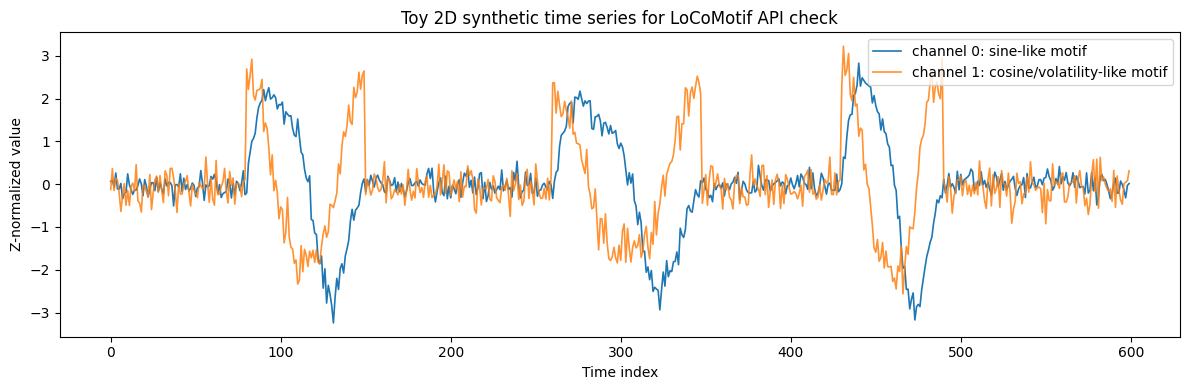

Saved toy time series plot to: c:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\results\locomotif_api_check\toy_timeseries.png


In [6]:
def znormalize_2d(x):
    """Column-wise z-normalization for 2D arrays with zero-variance protection."""
    arr = np.asarray(x, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D array, got shape {arr.shape}")
    mean = np.nanmean(arr, axis=0, keepdims=True)
    std = np.nanstd(arr, axis=0, keepdims=True)
    std = np.where((std == 0) | ~np.isfinite(std), 1.0, std)
    normalized = (arr - mean) / std
    return np.nan_to_num(normalized, nan=0.0, posinf=0.0, neginf=0.0)

np.random.seed(42)
n = 600
ts_raw = 0.08 * np.random.randn(n, 2)

starts = [80, 260, 430]
lengths = [70, 88, 60]
amplitudes = [1.0, 0.9, 1.1]

for start, length, amp in zip(starts, lengths, amplitudes):
    t = np.linspace(0, 2 * np.pi, length)
    motif_ch0 = amp * np.sin(t) + 0.18 * np.sin(2.5 * t)
    motif_ch1 = 0.7 * amp * np.cos(t) + 0.25 * np.exp(-((t - np.pi) ** 2) / 0.45)
    ts_raw[start:start + length, 0] += motif_ch0
    ts_raw[start:start + length, 1] += motif_ch1

ts = znormalize_2d(ts_raw)

print("ts.shape:", ts.shape)
print("np.mean(ts):", float(np.mean(ts)))
print("np.std(ts):", float(np.std(ts)))
print("first 5 rows:")
print(ts[:5])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ts[:, 0], label="channel 0: sine-like motif", linewidth=1.2)
ax.plot(ts[:, 1], label="channel 1: cosine/volatility-like motif", linewidth=1.2, alpha=0.85)
ax.set_title("Toy 2D synthetic time series for LoCoMotif API check")
ax.set_xlabel("Time index")
ax.set_ylabel("Z-normalized value")
ax.legend(loc="upper right")
fig.tight_layout()

toy_ts_path = OUTPUT_DIR / "toy_timeseries.png"
fig.savefig(toy_ts_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved toy time series plot to: {toy_ts_path}")

In [7]:
motif_sets = None

try:
    if locomotif_core is None or not hasattr(locomotif_core, "apply_locomotif"):
        raise RuntimeError("Cannot run LoCoMotif: locomotif_core.apply_locomotif is unavailable.")

    motif_sets = locomotif_core.apply_locomotif(
        ts,
        l_min=40,
        l_max=120,
        rho=0.6,
        overlap=0.2,
        nb=5,
        warping=True,
    )
    status["toy_run_successful"] = True
    try:
        status["toy_motif_sets_count"] = len(motif_sets)
    except TypeError:
        status["toy_motif_sets_count"] = None

    print("Raw motif_sets:")
    print(motif_sets)
    print("type(motif_sets):", type(motif_sets))
    try:
        print("len(motif_sets):", len(motif_sets))
    except TypeError as exc:
        print("len(motif_sets) unavailable:", exc)

except Exception as exc:
    status["toy_run_successful"] = False
    status["error_messages"].append(f"Toy LoCoMotif run failed: {exc}")
    print("Toy LoCoMotif run failed:", exc)

Raw motif_sets:
[((0, 80), [(np.int32(0), np.int32(80)), (np.int32(150), np.int32(260)), (np.int32(349), np.int32(430)), (np.int32(490), np.int32(598))]), ((64, 171), [(np.int32(64), np.int32(171)), (np.int32(240), np.int32(364)), (np.int32(414), np.int32(511))])]
type(motif_sets): <class 'list'>
len(motif_sets): 2


In [8]:
def _validate_interval(interval, label):
    if not isinstance(interval, (tuple, list)) or len(interval) != 2:
        raise ValueError(f"{label} must be a tuple/list of (start, end); got {interval!r}")
    start, end = interval
    if not isinstance(start, (int, np.integer)) or not isinstance(end, (int, np.integer)):
        raise ValueError(f"{label} start/end must be integers; got {interval!r}")
    start, end = int(start), int(end)
    if end <= start:
        raise ValueError(f"{label} end must be greater than start; got {interval!r}")
    return start, end

def parse_locomotif_result(motif_sets):
    """Parse expected LoCoMotif output: list of (candidate, motif_set) tuples."""
    if motif_sets is None:
        raise ValueError("motif_sets is None")
    if not isinstance(motif_sets, list):
        raise ValueError(f"Expected motif_sets to be a list, got {type(motif_sets)}")

    rows = []
    for motif_set_id, item in enumerate(motif_sets):
        if not isinstance(item, (tuple, list)) or len(item) != 2:
            raise ValueError(
                f"Motif set {motif_set_id} must be (candidate, motif_set); got {item!r}"
            )

        candidate, occurrences = item
        candidate_start, candidate_end = _validate_interval(candidate, f"candidate {motif_set_id}")
        if not isinstance(occurrences, list):
            raise ValueError(f"motif_set {motif_set_id} must be a list, got {type(occurrences)}")

        occurrence_count = len(occurrences)
        rows.append(
            {
                "motif_set_id": motif_set_id,
                "role": "candidate",
                "start_idx": candidate_start,
                "end_idx": candidate_end,
                "length": candidate_end - candidate_start,
                "candidate_start_idx": candidate_start,
                "candidate_end_idx": candidate_end,
                "occurrence_count": occurrence_count,
            }
        )

        for occurrence in occurrences:
            occurrence_start, occurrence_end = _validate_interval(
                occurrence, f"occurrence in motif_set {motif_set_id}"
            )
            rows.append(
                {
                    "motif_set_id": motif_set_id,
                    "role": "occurrence",
                    "start_idx": occurrence_start,
                    "end_idx": occurrence_end,
                    "length": occurrence_end - occurrence_start,
                    "candidate_start_idx": candidate_start,
                    "candidate_end_idx": candidate_end,
                    "occurrence_count": occurrence_count,
                }
            )

    return pd.DataFrame(
        rows,
        columns=[
            "motif_set_id",
            "role",
            "start_idx",
            "end_idx",
            "length",
            "candidate_start_idx",
            "candidate_end_idx",
            "occurrence_count",
        ],
    )

toy_motif_df = pd.DataFrame()

try:
    toy_motif_df = parse_locomotif_result(motif_sets)
    status["toy_parse_successful"] = True
    toy_csv_path = OUTPUT_DIR / "toy_locomotif_motif_sets.csv"
    toy_motif_df.to_csv(toy_csv_path, index=False)
    print(toy_motif_df)
    print(f"Saved parsed toy motif sets to: {toy_csv_path}")
except Exception as exc:
    status["toy_parse_successful"] = False
    status["error_messages"].append(f"Toy LoCoMotif output parsing failed: {exc}")
    print("Toy LoCoMotif output parsing failed:", exc)

   motif_set_id        role  start_idx  end_idx  length  candidate_start_idx  \
0             0   candidate          0       80      80                    0   
1             0  occurrence          0       80      80                    0   
2             0  occurrence        150      260     110                    0   
3             0  occurrence        349      430      81                    0   
4             0  occurrence        490      598     108                    0   
5             1   candidate         64      171     107                   64   
6             1  occurrence         64      171     107                   64   
7             1  occurrence        240      364     124                   64   
8             1  occurrence        414      511      97                   64   

   candidate_end_idx  occurrence_count  
0                 80                 4  
1                 80                 4  
2                 80                 4  
3                 80               

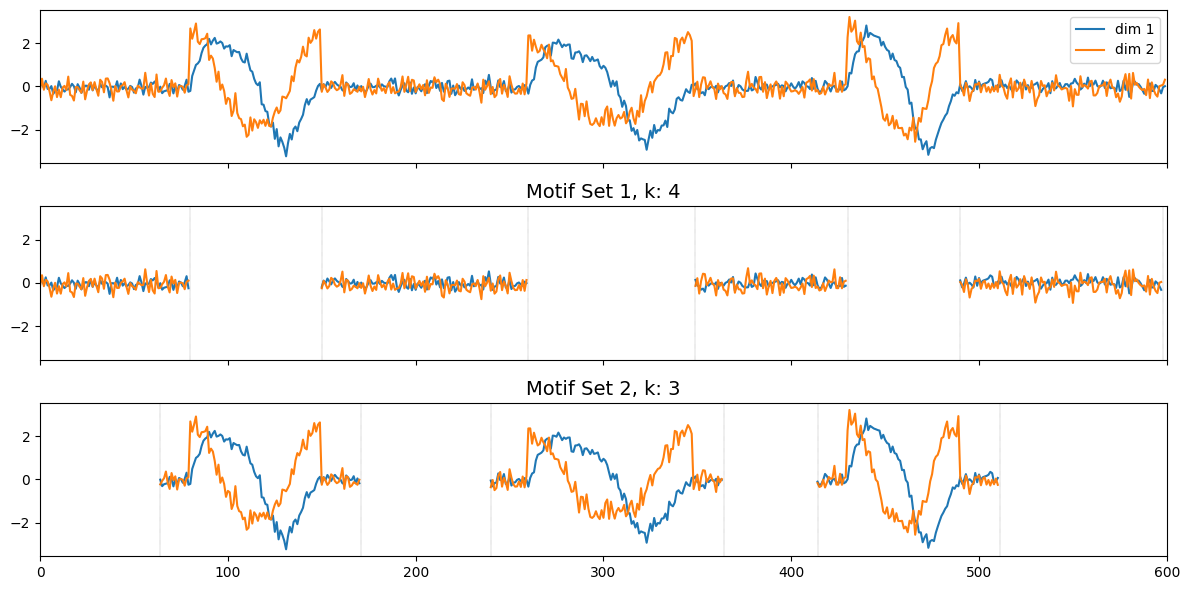

Saved official LoCoMotif plot to: c:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\results\locomotif_api_check\toy_locomotif_official_plot.png


In [9]:
def plot_custom_motif_sets(ts_array, parsed_df):
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(ts_array[:, 0], color="black", linewidth=1.0, label="channel 0")
    if parsed_df is not None and not parsed_df.empty:
        for _, row in parsed_df.iterrows():
            color = "tab:red" if row["role"] == "candidate" else "tab:blue"
            alpha = 0.28 if row["role"] == "candidate" else 0.16
            ax.axvspan(int(row["start_idx"]), int(row["end_idx"]), color=color, alpha=alpha)
    ax.set_title("LoCoMotif motif intervals on toy time series (custom visualization fallback)")
    ax.set_xlabel("Time index")
    ax.set_ylabel("Channel 0 z-score")
    ax.legend(loc="upper right")
    fig.tight_layout()
    return fig, ax

try:
    if visualize is None or not hasattr(visualize, "plot_motif_sets"):
        raise RuntimeError("locomotif.visualize.plot_motif_sets is unavailable")
    fig, ax = visualize.plot_motif_sets(ts, motif_sets)
    official_plot_path = OUTPUT_DIR / "toy_locomotif_official_plot.png"
    plt.savefig(official_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved official LoCoMotif plot to: {official_plot_path}")
except Exception as exc:
    status["error_messages"].append(f"Official LoCoMotif visualization failed; used custom fallback: {exc}")
    print("Official visualization failed; creating custom fallback plot:", exc)
    fig, ax = plot_custom_motif_sets(ts, toy_motif_df)
    custom_plot_path = OUTPUT_DIR / "toy_locomotif_custom_plot.png"
    fig.savefig(custom_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved custom fallback plot to: {custom_plot_path}")

In [10]:
fake_finance_motif_sets = None
fake_finance_motif_df = pd.DataFrame()

try:
    if locomotif_core is None or not hasattr(locomotif_core, "apply_locomotif"):
        raise RuntimeError("Cannot run finance-shaped test: locomotif_core.apply_locomotif is unavailable.")

    np.random.seed(42)
    fake_returns = 0.001 + 0.02 * np.random.randn(1000)
    shock_window = slice(420, 520)
    fake_returns[shock_window] += 0.035 * np.sin(np.linspace(0, 5 * np.pi, shock_window.stop - shock_window.start))
    returns_series = pd.Series(fake_returns)
    rolling_vol = returns_series.rolling(window=20, min_periods=2).std().bfill().to_numpy()
    finance_ts = znormalize_2d(np.column_stack([fake_returns, rolling_vol]))

    fake_finance_motif_sets = locomotif_core.apply_locomotif(
        finance_ts,
        l_min=30,
        l_max=120,
        rho=0.6,
        overlap=0.2,
        nb=5,
        warping=True,
    )
    status["fake_finance_run_successful"] = True
    print("Fake finance motif_sets:")
    print(fake_finance_motif_sets)

    fake_finance_motif_df = parse_locomotif_result(fake_finance_motif_sets)
    status["fake_finance_parse_successful"] = True
    finance_csv_path = OUTPUT_DIR / "fake_finance_locomotif_motif_sets.csv"
    fake_finance_motif_df.to_csv(finance_csv_path, index=False)
    print(fake_finance_motif_df)
    print(f"Saved fake finance parsed motif sets to: {finance_csv_path}")

except Exception as exc:
    status["fake_finance_run_successful"] = False
    status["fake_finance_parse_successful"] = False
    status["error_messages"].append(f"Fake finance LoCoMotif compatibility test failed: {exc}")
    print("Fake finance LoCoMotif compatibility test failed:", exc)

Fake finance motif_sets:
[((554, 597), [(np.int32(554), np.int32(597)), (np.int32(54), np.int32(100)), (np.int32(93), np.int32(145)), (np.int32(900), np.int32(958)), (np.int32(154), np.int32(198)), (np.int32(694), np.int32(731)), (np.int32(799), np.int32(849)), (np.int32(194), np.int32(243)), (np.int32(728), np.int32(781)), (np.int32(957), np.int32(995)), (np.int32(600), np.int32(638)), (np.int32(854), np.int32(898)), (np.int32(22), np.int32(62)), (np.int32(243), np.int32(289)), (np.int32(368), np.int32(409))]), ((773, 803), [(np.int32(773), np.int32(803)), (np.int32(145), np.int32(163)), (np.int32(532), np.int32(557)), (np.int32(280), np.int32(309))]), ((643, 674), [(np.int32(643), np.int32(674)), (np.int32(498), np.int32(536))]), ((0, 30), [(np.int32(0), np.int32(30)), (np.int32(318), np.int32(349))])]
    motif_set_id        role  start_idx  end_idx  length  candidate_start_idx  \
0              0   candidate        554      597      43                  554   
1              0  occu

In [11]:
status["ready_for_thesis_integration"] = bool(
    status.get("package_imported")
    and status.get("core_imported")
    and status.get("apply_locomotif_found")
    and status.get("toy_run_successful")
    and status.get("toy_parse_successful")
)

if status["ready_for_thesis_integration"]:
    status["next_action"] = "Create 01_real_locomotif_btc_eth_small_slice.ipynb for a small real BTC/ETH integration slice."
else:
    blockers = [
        key for key in [
            "package_imported",
            "core_imported",
            "apply_locomotif_found",
            "toy_run_successful",
            "toy_parse_successful",
        ]
        if not status.get(key)
    ]
    status["next_action"] = f"Inspect locomotif_status.json and pip/module logs; blockers: {blockers}."

final_status = {
    "package_name": status.get("package_name"),
    "import_name": status.get("import_name"),
    "expected_function": status.get("expected_function"),
    "package_installed": bool(status.get("package_installed")),
    "package_imported": bool(status.get("package_imported")),
    "core_imported": bool(status.get("core_imported")),
    "visualize_imported": bool(status.get("visualize_imported")),
    "apply_locomotif_found": bool(status.get("apply_locomotif_found")),
    "toy_run_successful": bool(status.get("toy_run_successful")),
    "toy_motif_sets_count": status.get("toy_motif_sets_count"),
    "fake_finance_run_successful": bool(status.get("fake_finance_run_successful")),
    "ready_for_thesis_integration": bool(status.get("ready_for_thesis_integration")),
    "error_messages": status.get("error_messages", []),
    "next_action": status.get("next_action"),
}

status_json_path = OUTPUT_DIR / "locomotif_status.json"
status_json_path.write_text(json.dumps(final_status, indent=2), encoding="utf-8")

print(json.dumps(final_status, indent=2))
print(f"Saved final status JSON to: {status_json_path}")

if final_status["ready_for_thesis_integration"]:
    print("\n✅ Ready for thesis integration")
else:
    blockers = [
        key for key in [
            "package_imported",
            "core_imported",
            "apply_locomotif_found",
            "toy_run_successful",
            "toy_parse_successful",
        ]
        if not status.get(key)
    ]
    print(f"\n❌ Not ready, exact blocker is: {blockers}")

{
  "package_name": "dtai-locomotif",
  "import_name": "locomotif.locomotif",
  "expected_function": "apply_locomotif",
  "package_installed": true,
  "package_imported": true,
  "core_imported": true,
  "visualize_imported": true,
  "apply_locomotif_found": true,
  "toy_run_successful": true,
  "toy_motif_sets_count": 2,
  "fake_finance_run_successful": true,
  "ready_for_thesis_integration": true,
  "error_messages": [],
  "next_action": "Create 01_real_locomotif_btc_eth_small_slice.ipynb for a small real BTC/ETH integration slice."
}
Saved final status JSON to: c:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\results\locomotif_api_check\locomotif_status.json

✅ Ready for thesis integration


## Conclusion

If the final status reports readiness, the next step is to create `01_real_locomotif_btc_eth_small_slice.ipynb` and run LoCoMotif on a small, controlled BTC/ETH data slice.

If the final status reports that it is not ready, inspect `reports/results/locomotif_api_check/locomotif_status.json`, `pip_show_dtai_locomotif.txt`, and `locomotif_public_names.txt` to identify the installation, import, API, execution, or parsing blocker.

This notebook intentionally does not run on real BTC/ETH data and does not create proxy, placeholder, or DTW-substitute motif results.